# Paquetes

In [294]:
using PhysicalConstants
using PhysicalConstants.CODATA2022: ħ, m_e, c_0
using Unitful
using Plots
using CSV
using DataFrames

# Funciones

In [303]:
function Kronig_Penney(E, ω, b, V₀; m_eff = 0.067, normalizado = false, compacto = false)
    
    a = ω + b
    
    # estas dos variables las añado para que el coseno de k₁ y k₂ no haga overflow
    mₑc² = ustrip(uconvert(u"eV", m_e*c_0^2))                 # en EV
    ħc = ustrip(uconvert(u"eV*nm", ħ*c_0))                    # en eV nm

    k₁ = @. sqrt(2 * m_eff * mₑc² * E) / ħc                   # en nm⁻¹
    k₂ = @. sqrt(Complex(2 * m_eff * mₑc² * (E - V₀))) / ħc   # en nm⁻¹
    
    # Valor de cos(ka), con esto vemos las bandas imponiendo que f este entre -1 y +1
    f = @. cos(k₁*ω)*cos(k₂*b) - ((k₁^2 + k₂^2) / (2 * k₁ * k₂)) * sin(k₁*ω)*sin(k₂*b)
    
    banda = real.(f)
    
    k_eff, E_eff = Calcular_k(E, banda, a, normalizado, compacto)
    
    return banda, k_eff, E_eff
end



function Calcular_k(E, band, a, normalizar, compactar)
    
    Es = []
    ks = []
    counter = -0.5 * !compactar
    
    for i in 2:length(band)
        if ((abs(band[i]) < 1.0) ⊻ (abs(band[i-1]) < 1.0))
            counter += 0.5 * !compactar
        end
        if (abs(band[i]) <= 1.0)
            push!(Es, E[i])
            if normalizar
                push!(ks, (1 - 2 * !es_par(counter)) * (acos(band[i])/π) + es_entero(counter) * (counter + !es_par(counter)))           # en unidades de π/a
            else
                push!(ks, (1 - 2 * !es_par(counter)) * (acos(band[i])/a) + es_entero(counter) * (counter + !es_par(counter) ) * π / a)  # k en nm⁻¹
            end
        end
    end
    
    return ks, Es
end

function es_par(x)
    return x % 2 == 0
end

function es_entero(x)
    return x % 1 == 0
end

function compute_v(E, k)
    v = zeros(length(E))
    eV_to_J = 1.602176634e-19
    nm_inv_to_m_inv = 1e9
    for i in 2:length(E)
        Δk = (k[i] - k[i-1]) * nm_inv_to_m_inv
        ΔE = (E[i] - E[i-1]) * eV_to_J
        v[i] = ΔE / Δk / ustrip(ħ)
        if v[i] > 1e7
            v[i] = NaN
        end
    end
    return v
end

function n_to_k_fit(n, N, a; normalizado = true)
    k = @. 2 / N * (0.559 * n - 0.5674) * (π / a)^!normalizado
    return k 
end

n_to_k_fit (generic function with 1 method)

In [245]:
c_0

Speed of light in vacuum (c_0)
Value                         = 2.99792458e8 m s^-1
Standard uncertainty          = (exact)
Relative standard uncertainty = (exact)
Reference                     = CODATA 2022

# Datos

In [255]:
Energy = 0:0.00005:1.0
Barrier_Potential = 0.4
Barrier_width = 2.0
Well_width = 6.0
banda, k_bandas, E_bandas = Kronig_Penney(Energy,Well_width,Barrier_width,Barrier_Potential, normalizado = false, compacto = false)

([NaN, 9.256709426403024, 9.246689029738468, 9.236675123793503, 9.226667705592828, 9.216666772162187, 9.206672320528389, 9.196684347719273, 9.186702850763737, 9.17672782669173  …  -0.8633965239993094, -0.8632339847639082, -0.8630713826900119, -0.8629087177963928, -0.8627459901018298, -0.8625831996250998, -0.8624203463849819, -0.8622574304002593, -0.862094451689717, -0.8619314102721415], Any[0.00788858212907857, 0.013663174323375096, 0.01764057099103801, 0.020874676308571694, 0.02367212659534361, 0.02617331258759355, 0.02845646502291908, 0.030570476858219703, 0.03254832410475545, 0.034413494319342056  …  1.2442013493507278, 1.2442416085422943, 1.2442818611245525, 1.2443221071079358, 1.2443623465028484, 1.2444025793196694, 1.2444428055687506, 1.2444830252604167, 1.2445232384049658, 1.2445634450126692], Any[0.0617, 0.06175, 0.0618, 0.06185, 0.0619, 0.06195, 0.062, 0.06205, 0.0621, 0.06215  …  0.99955, 0.9996, 0.99965, 0.9997, 0.99975, 0.9998, 0.99985, 0.9999, 0.99995, 1.0])

# Gráficos

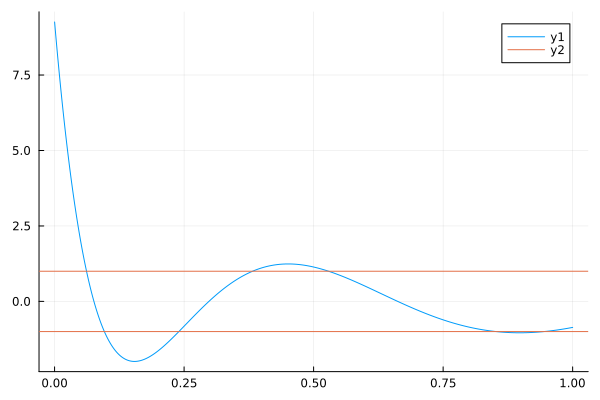

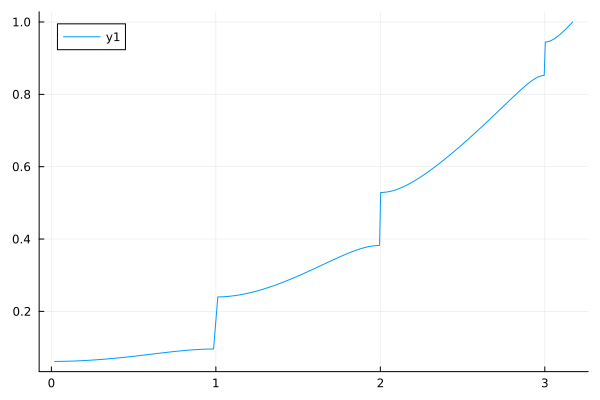

In [248]:
p1 = plot(Energy, banda)
hline!([1.0, -1.0])
p2 = plot(k_bandas,E_bandas)

display(p1)
display(p2)

In [319]:
#################################
# ESTO NO FUNCIONA BIEN TODAVIA #
#################################
function leer_archivo_csv(carpeta, archivo; usuario = "JRcodes73")
    ruta = joinpath(@__DIR__, "..", carpeta, archivo)
    ruta = normpath(ruta)
    # l_ruta = length(archivo)
    # posible_usuario = archivo[l_ruta-length(usuario):l_ruta-1]
    # if posible_usuario == usuario
    #     exit
    # end
    println(ruta)
    data = CSV.read(ruta, DataFrame, header = 4)
    return data
end
prueba = leer_archivo_csv("Pruebas", "30_pozos_04.txt")

c:\Users\JRSucks73\Documents\GNOMOS\JRcodes73\Pruebas\30_pozos_04.txt


Row,Occurrence,Resonance Energy (eV)
,Int64,Float64
1,1,0.0617651
2,2,0.061972
3,3,0.0623157
4,4,0.0627954
5,5,0.0634082
6,6,0.0641504
7,7,0.0650195
8,8,0.0660254
9,9,0.0671387


In [314]:
ocurrencia_to_k = (prueba.Occurrence .- 0.5) ./ 200

630-element Vector{Float64}:
 0.0025
 0.0075
 0.0125
 0.0175
 0.0225
 0.0275
 0.0325
 0.0375
 0.0425
 0.0475
 ⋮
 3.1075
 3.1125
 3.1175
 3.1225
 3.1275
 3.1325
 3.1375
 3.1425
 3.1475

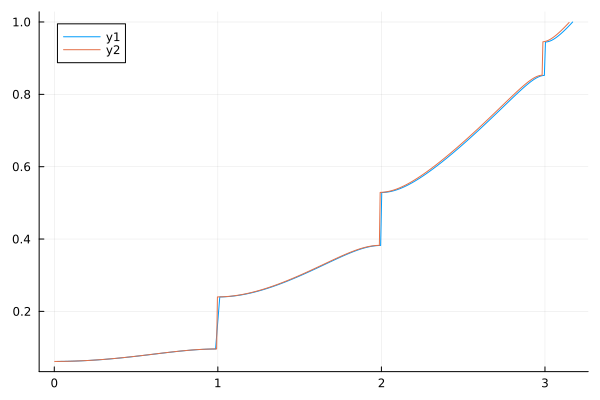

In [243]:
plot!(p2, ocurrencia_to_k, prueba[:,2])


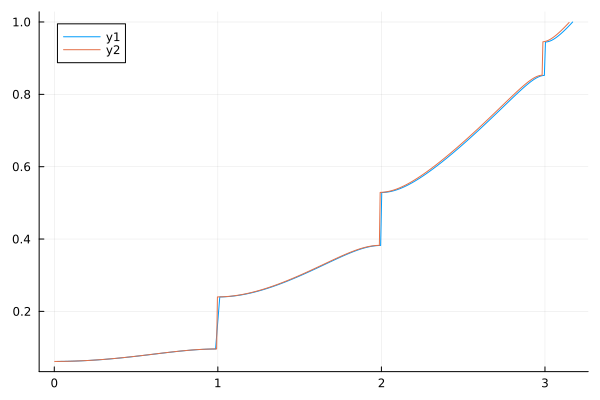

In [244]:
display(p2)

c:\Users\JRSucks73\Documents\GNOMOS\JRcodes73\Pruebas\30_pozos_04.txt


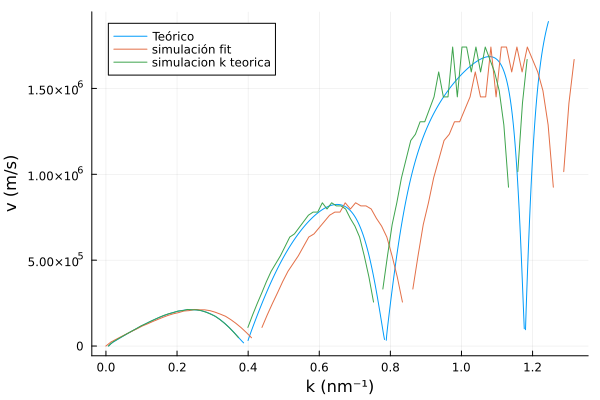

In [322]:
prueba = leer_archivo_csv("Pruebas", "30_pozos_04.txt")
v_g = compute_v(E_bandas,k_bandas)
velocidad = plot(k_bandas,v_g, xlabel = "k (nm⁻¹)", ylabel = "v (m/s)", label = "Teórico")

ocurrencias = prueba.Occurrence
E_sim = prueba[:,2]
a = Barrier_width + Well_width
N = 30
k_sim_fit = n_to_k_fit(ocurrencias, N, a, normalizado = false)
k_sim = (prueba.Occurrence .- 0.5) ./ 30 .* π ./ a
v_sim = compute_v(E_sim, k_sim)
plot!(velocidad, k_sim_fit, v_sim, label = "simulación fit")
plot!(velocidad, k_sim, v_sim, label = "simulacion k teorica")
